In [75]:
%pip install -q scikit-learn joblib seaborn torch transformers datasets accelerate


Note: you may need to restart the kernel to use updated packages.


In [76]:
import json
from pathlib import Path
from tqdm.auto import tqdm 
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)


In [77]:
df_orig = pd.read_csv("data1.csv")
df = df_orig.copy()


In [78]:
df1 = pd.read_csv("data2.csv")


In [79]:
# объединяем df1 и df
df = pd.concat([df, df1], ignore_index=True)
print(f"Объединённый датафрейм: {df.shape}")
print(f"Распределение классов:")
print(df["toxic"].value_counts())

Объединённый датафрейм: (19363, 2)
Распределение классов:
toxic
0.0    11434
1.0     7919
Name: count, dtype: int64


In [80]:
import re

def super_clean_text(text):
    text = str(text)
    text = text.lower()
    cleaned = re.sub(r'[^a-zа-яё0-9\s]', '', text)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

In [81]:
df = df.dropna(subset=["comment", "toxic"])
df['comment'] = df['comment'].apply(super_clean_text)
df["comment"] = df["comment"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df["toxic"] = df["toxic"].astype(int)
df = df[df["comment"] != ""].drop_duplicates(subset="comment").reset_index(drop=True)

print(df.shape)


(18586, 2)


In [82]:
# разбиваем на train/valid/test, сохраняя пропорцию классов (stratify) и фиксируя random_state для воспроизводимости
X = df["comment"]
y = df["toxic"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42,
)

print("Train:")
display(y_train.value_counts(normalize=True).sort_index().rename("share").to_frame())
print("Valid:")
display(y_valid.value_counts(normalize=True).sort_index().rename("share").to_frame())
print("Test:")
display(y_test.value_counts(normalize=True).sort_index().rename("share").to_frame())


Train:


,share
toxic,
0,0.600307
1,0.399693


Valid:


,share
toxic,
0,0.600072
1,0.399928


Test:


,share
toxic,
0,0.60043
1,0.39957


In [83]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)


In [96]:
# Сетка для поиска по СЛОВАМ (и фразам)
grid_words = ParameterGrid({
    "analyzer": ["word"],
    "ngram_range": [(1, 2), (1, 3), (2, 3)], 
    "min_df": [2, 3],                        
    "sublinear_tf": [True],                  
    "binary": [True, False]                  
}) 

# Сетка для поиска по СИМВОЛАМ
grid_chars = ParameterGrid({
    "analyzer": ["char", "char_wb"],         
    "ngram_range": [(3, 5), (3, 6)],         
    "min_df": [3, 5],                        
    "max_features": [None, 30000],           
    "sublinear_tf": [True]                   
})

# ГЕНЕРИРУЕМ КАНДИДАТОВ 
baseline_candidates = []

# Распаковываем слова
for i, params in enumerate(grid_words):
    baseline_candidates.append({
        "name": f"word_model_{i+1}", 
        "params": params
    })

# Распаковываем символы
for i, params in enumerate(grid_chars):
    baseline_candidates.append({
        "name": f"char_model_{i+1}", 
        "params": params
    })

print(f"тестирование {len(baseline_candidates)} моделей...\n")

# ГЛАВНЫЙ ЦИКЛ ОБУЧЕНИЯ С ПРОГРЕСС-БАРОМ 
baseline_results = []

# Оборачиваем список в tqdm
pbar = tqdm(baseline_candidates, desc="Подготовка...")

for candidate in pbar:
    pbar.set_description(f"Обучаю {candidate['name']}")
    
    # Векторизация текста
    vectorizer = TfidfVectorizer(**candidate["params"])
    X_train_vec = vectorizer.fit_transform(X_train)
    X_valid_vec = vectorizer.transform(X_valid)

    # Обучение модели
    model = LogisticRegression(
        class_weight="balanced", 
        max_iter=2000, 
        solver="liblinear", 
        random_state=42,
    )
    model.fit(X_train_vec, y_train)

    # вероятности токсичности
    valid_proba = model.predict_proba(X_valid_vec)[:, 1]

    # Перебираем 200 вариантов строгости (порогов)
    threshold_rows = []
    for threshold in np.linspace(0.05, 0.95, 200):
        valid_pred = (valid_proba >= threshold).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_valid,
            valid_pred,
            average="binary", 
            zero_division=0,
        )
        threshold_rows.append({
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    threshold_curve = pd.DataFrame(threshold_rows)
    best_row = threshold_curve.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
    best_threshold = float(best_row["threshold"])

    # Сохраняем все результаты
    baseline_results.append({
        "name": candidate["name"],
        "params": candidate["params"], 
        "vectorizer": vectorizer,
        "model": model,
        "threshold": best_threshold,
        "threshold_curve": threshold_curve,
        "validation_f1": float(best_row["f1"]),
        "validation_precision": float(best_row["precision"]),
        "validation_recall": float(best_row["recall"]),
    })
    

#ФОРМИРУЕМ ФИНАЛЬНУЮ ТАБЛИЦУ ПОБЕДИТЕЛЕЙ
print("\nИтог")

baseline_summary = pd.DataFrame([
    {
        "Модель": result["name"],
        "F1": round(result["validation_f1"], 4),
        "Precision": round(result["validation_precision"], 4),
        "Recall": round(result["validation_recall"], 4),
        "Идеальный порог": round(result["threshold"], 4),
        "Параметры TF-IDF": result["params"], 
    }
    for result in baseline_results
]).sort_values(["F1", "Precision", "Recall"], ascending=False).reset_index(drop=True)

print("\nТОП-5:")
baseline_summary.head(5)

тестирование 28 моделей...



Подготовка...:   0%|          | 0/28 [00:00<?, ?it/s]


Итог

ТОП-5:


,Модель,F1,Precision,Recall,Идеальный порог,Параметры TF-IDF
0,char_model_9,0.8810,0.8632,0.8996,0.4796,"{'analyzer': 'char_wb', 'max_features': None, 'min_df': 3, 'ngram_range': (3, 5), 'sublinear_tf': True}"
1,char_model_11,0.8807,0.8618,0.9004,0.4751,"{'analyzer': 'char_wb', 'max_features': None, 'min_df': 5, 'ngram_range': (3, 5), 'sublinear_tf': True}"
2,char_model_12,0.8795,0.8784,0.8807,0.4932,"{'analyzer': 'char_wb', 'max_features': None, 'min_df': 5, 'ngram_range': (3, 6), 'sublinear_tf': True}"
3,char_model_10,0.8793,0.8641,0.8951,0.4796,"{'analyzer': 'char_wb', 'max_features': None, 'min_df': 3, 'ngram_range': (3, 6), 'sublinear_tf': True}"
4,char_model_15,0.8752,0.8611,0.8897,0.4751,"{'analyzer': 'char_wb', 'max_features': 30000, 'min_df': 5, 'ngram_range': (3, 5), 'sublinear_tf': True}"


In [97]:
best_baseline = sorted(
    baseline_results,
    key=lambda x: (x["validation_f1"], x["validation_precision"], x["validation_recall"]),
    reverse=True,
)[0]

baseline_vectorizer = best_baseline["vectorizer"]
baseline_model = best_baseline["model"]
baseline_threshold = best_baseline["threshold"]

print("Лучшая baseline-модель:", best_baseline["name"])
print("Лучший threshold:", baseline_threshold)

joblib.dump(
    {
        "kind": "baseline",
        "name": best_baseline["name"],
        "vectorizer": baseline_vectorizer,
        "model": baseline_model,
        "threshold": baseline_threshold,
    },
    artifacts_dir / "baseline.joblib",
)


Лучшая baseline-модель: char_model_9
Лучший threshold: 0.4796482412060301


['artifacts\\baseline.joblib']

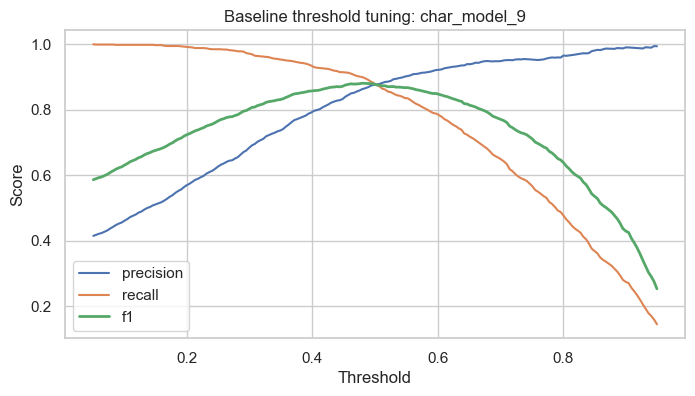

In [98]:
plt.figure(figsize=(8, 4))
plt.plot(best_baseline["threshold_curve"]["threshold"], best_baseline["threshold_curve"]["precision"], label="precision")
plt.plot(best_baseline["threshold_curve"]["threshold"], best_baseline["threshold_curve"]["recall"], label="recall")
plt.plot(best_baseline["threshold_curve"]["threshold"], best_baseline["threshold_curve"]["f1"], label="f1", linewidth=2)
plt.title(f"Baseline threshold tuning: {best_baseline['name']}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()


Baseline validation classification report:
              precision    recall  f1-score   support

           0     0.9311    0.9050    0.9179      1673
           1     0.8632    0.8996    0.8810      1115

    accuracy                         0.9028      2788
   macro avg     0.8971    0.9023    0.8994      2788
weighted avg     0.9039    0.9028    0.9031      2788



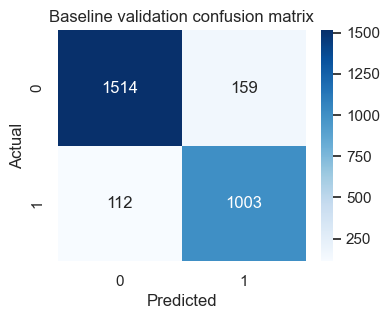

Baseline test classification report:
              precision    recall  f1-score   support

           0     0.9262    0.8990    0.9124      1674
           1     0.8547    0.8923    0.8731      1114

    accuracy                         0.8963      2788
   macro avg     0.8904    0.8957    0.8927      2788
weighted avg     0.8976    0.8963    0.8967      2788



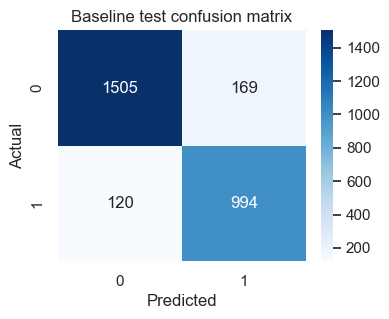

,split,threshold,accuracy,precision,recall,f1,macro_f1,roc_auc,pr_auc
0,validation,0.479648,0.902798,0.863167,0.899552,0.880984,0.899419,0.958052,0.938453
1,test,0.479648,0.896341,0.854686,0.892280,0.873079,0.892738,0.951850,0.937556


In [99]:
# ОЦЕНИВАЕМ ЛУЧШИЙ BASELINE НА ВАЛИДАЦИИ И ТЕСТЕ
baseline_metrics_rows = []

for split_name, X_part, y_part in [
    ("validation", X_valid, y_valid),
    ("test", X_test, y_test),
]:
    X_part_vec = baseline_vectorizer.transform(X_part)
    part_proba = baseline_model.predict_proba(X_part_vec)[:, 1]
    part_pred = (part_proba >= baseline_threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_part,
        part_pred,
        average="binary",
        zero_division=0,
    )
    macro_f1 = f1_score(y_part, part_pred, average="macro", zero_division=0)
    accuracy = accuracy_score(y_part, part_pred)
    roc_auc = roc_auc_score(y_part, part_proba)
    pr_auc = average_precision_score(y_part, part_proba)
    cm = confusion_matrix(y_part, part_pred)

    baseline_metrics_rows.append(
        {
            "split": split_name,
            "threshold": baseline_threshold,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "macro_f1": macro_f1,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "confusion_matrix": cm.tolist(),
        }
    )

    print(f"Baseline {split_name} classification report:")
    print(classification_report(y_part, part_pred, digits=4, zero_division=0))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Baseline {split_name} confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

baseline_metrics = pd.DataFrame(
    [{k: v for k, v in row.items() if k != "confusion_matrix"} for row in baseline_metrics_rows]
)
display(baseline_metrics)

baseline_test_metrics = baseline_metrics_rows[1]


Экспорт

In [88]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [89]:
%pip install -q skl2onnx onnxconverter-common

Note: you may need to restart the kernel to use updated packages.


In [90]:
import joblib
from sklearn.pipeline import Pipeline
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import StringTensorType
import subprocess

best_baseline = joblib.load("artifacts/baseline.joblib") 
vectorizer = best_baseline["vectorizer"]
model = best_baseline["model"]

# Собираем пайплайн
pipeline = Pipeline([
    ("tfidf", vectorizer),
    ("classifier", model)
])

initial_type = [('text_input', StringTensorType([None, 1]))]

# Попробуем onnxmltools - он лучше поддерживает sklearn
import onnxmltools



onnx_model = onnxmltools.convert_sklearn(
    pipeline,
    initial_types=[('text_input', StringTensorType([None, 1]))]
)
    
with open("artifacts/toxic_classifier_word.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())
    
print("ONNX модель успешно экспортирована (onnxmltools)")


c:\Users\Дарья\AppData\Local\Programs\Python\Python311\Lib\site-packages\skl2onnx\operator_converters\text_vectoriser.py:203: UserWarning: The conversion of CountVectorizer may not work. only tokenizer='word' is fully supported. You may raise an issue at https://github.com/onnx/sklearn-onnx/issues.
  warnings.warn(


ONNX модель успешно экспортирована (onnxmltools)


In [91]:
%pip install onnxruntime


Note: you may need to restart the kernel to use updated packages.


In [92]:
import onnxruntime as ort

session = ort.InferenceSession("artifacts/toxic_classifier_word.onnx")


In [93]:
print(session.get_inputs())
print(session.get_outputs())

[<onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x00000178AD0E88B0>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x00000178AD0E9B70>]


In [94]:
session.get_inputs()

In [ ]:
texts = np.array([
    ["Ты дурак глупый"],
    ["Какой прекрасный день!"],
    ["Я не знаю, что сказать..."]
])
outputs = session.run(
    None,
    {"text_input": texts}
)

print(outputs)

[array([1, 1, 0]), [{0: 0.03252407908439636, 1: 0.9674758911132812}, {0: 0.45439407229423523, 1: 0.5456058979034424}, {0: 0.6981093287467957, 1: 0.30189067125320435}]]
